In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/mnist_0_and_1.csv')

TASK 1

AND Gate using MCP Neuron:

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.

    Output:
    state_neuron (1D list): State of neuron (1 or 0)
    """

    assert len(X1) == len(X2)

    state_neuron = []  # store outputs

    # Element-wise addition and threshold check
    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
#Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(result)

[0, 0, 0, 1]


OR Gate using MCP Neuron:


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    """

    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [ ]:
#Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(result_or)

[0, 1, 1, 1]


TASK 2

Load the Dataset

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df_0_1 = pd.read_csv('/content/mnist_0_and_1.csv')

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

# Check shape
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Visualize the Dataset

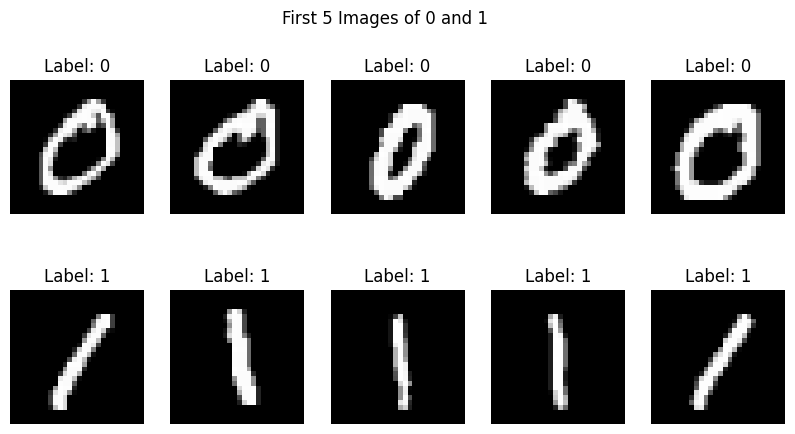

In [ ]:
import matplotlib.pyplot as plt

images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1")
plt.show()

Initialize Weights and Bias

In [ ]:
weights = np.zeros(X.shape[1])  # 784 features
bias = 0
learning_rate = 0.1
epochs = 100

Decision Function

In [ ]:
import numpy as np
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

Train Perceptorn

In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        for i in range(len(X)):

            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)

    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

Train Model

Viaualize Misclassified Image

In [12]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
   fig, axes = plt.subplots(2, 5, figsize=(10, 5))
   for ax, idx in zip(axes.flat, misclassified_idx[:10]): # Show 10 misclassified images
       ax.imshow(X[idx].reshape(28, 28), cmap="gray")
       ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
       ax.axis("off")
   plt.suptitle("Misclassified Images")
   plt.show()
else:
   print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Perceptron for 3 vs 5 Classification

In [13]:
# Load dataset for 3 and 5
df_3_5 = pd.read_csv('/content/mnist_3_and_5.csv')

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [14]:
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0

In [15]:
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35, weights_35, bias_35
)

print("Final Accuracy (3 vs 5):", accuracy_35)

Final Accuracy (3 vs 5): 0.0


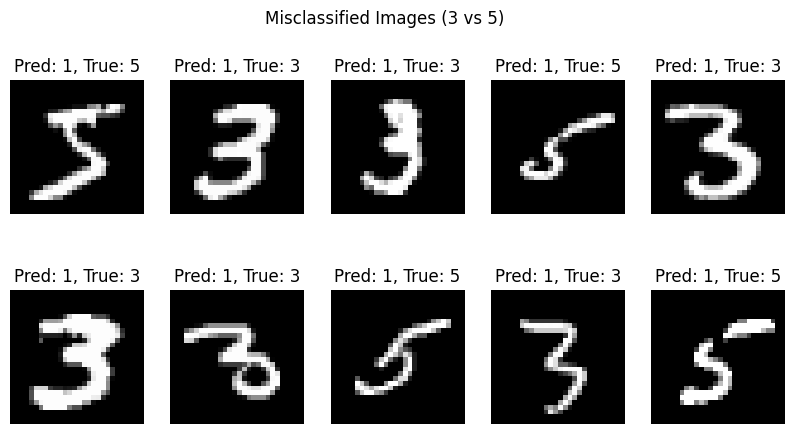

In [16]:
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

misclassified_idx_35 = np.where(y_pred_35 != y_35)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred_35[idx]}, True: {y_35[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")